# Video-and-Language Action Recognition in Egocentric Kitchens

**Project 11 | EPIC-KITCHENS-100 — Participant P01 Subset**

---

| | |
|:---|:---|
| **Course** | Machine Learning |
| **Group Number** | Group 11 |
| **Team Members** | Uzoma Eze — Matriculation No. 41721344 |
| | Amrin Yanya — Matriculation No. 68788172 |
| | Magomed Makhsudov — Matriculation No. 57870374 |
| **Date** | 22 June 2026 |

---

> *Can we recognise fine-grained cooking actions from egocentric video by fusing language narrations, object cues, and video frames using frozen pretrained encoders?*

---
## Table of Contents

1. [Problem Statement](#1-problem-statement)
2. [Dataset](#2-dataset)
3. [Methodology](#3-methodology)
4. [Selected Models](#4-selected-models)
5. [Evaluation Criterion](#5-evaluation-criterion)
6. [Results](#6-results)
7. [Error Analysis and Limitations](#7-error-analysis-and-limitations)
8. [Conclusion](#8-conclusion)
9. [Code Demonstration](#9-code-demonstration)

---
## 1. Problem Statement

**Central question:** *Can fusing language narrations, object labels, and visual frame features improve fine-grained action recognition in egocentric kitchen videos — especially for rare, tail-class actions?*

- **Task:** Given a short first-person video clip, predict the **verb** (e.g. *cut*, *put-down*) and **noun** (e.g. *tomato*, *pan*) that together form an **action** label (e.g. *cut tomato*).
- **Domain:** EPIC-KITCHENS-100, participant P01 — 22 kitchen sessions totalling 6,394+ annotated clips.
- **Why multimodal?** No single modality is sufficient: video alone struggles with fine-grained motion; text alone reveals what the narrator *says* (not what actually happens on screen); object cues tell us *what* is present but not *what is done* with it.
- **Core challenge:** Severe long-tail class imbalance — *take* and *put-down* together account for over 2,000 clips, while dozens of verbs appear fewer than 10 times; standard accuracy hides this.
- **Strategy:** Freeze large pretrained encoders (Sentence-BERT, CLIP) and train only a compact MLP fusion head — maximising accuracy within compute constraints.

In [78]:
import pandas as pd, warnings
from IPython.display import display
warnings.filterwarnings('ignore')

# Paths are relative to the notebook (project root)
TRAIN_CSV = "data/train_metadata.csv"
DEMO_CSV  = "data/demo_metadata.csv"

train_df = pd.read_csv(TRAIN_CSV)
demo_df  = pd.read_csv(DEMO_CSV)

print("Sample annotated clips (demo set — P01_01):")
print("Demo Clips")
display(demo_df[["narration_id","narration","verb","noun","action_label"]].head(8))

Sample annotated clips (demo set — P01_01):
Demo Clips


,narration_id,narration,verb,noun,action_label
0,P01_01_0,open door,open,door,open door
1,P01_01_1,turn on light,turn-on,light,turn-on light
2,P01_01_2,close door,close,door,close door
3,P01_01_3,open fridge,open,fridge,open fridge
4,P01_01_4,take celery,take,celery,take celery
5,P01_01_5,take container,take,container,take container
6,P01_01_6,take tofu,take,tofu,take tofu
7,P01_01_7,close fridge,close,fridge,close fridge


---
## 2. Dataset

**Source:** EPIC-KITCHENS-100 ([data.bris.ac.uk](https://data.bris.ac.uk/data/dataset/2g1n6qdydwa9u22shpxqzp0t8m)), subset restricted to **Participant P01**.

- **Format:** First-person (egocentric) video recorded in a kitchen; each clip has a start/stop frame, a free-text narration spoken by the participant, and fine-grained verb + noun annotations.
- **Splits used:**

| Split | Clips | Videos | Labels? | Role |
|:---|---:|---:|:---|:---|
| Train | 5,509 | 22 | ✅ verb + noun | Model training |
| Val | 885 | 5 | ✅ verb + noun | Hyperparameter selection & evaluation |
| Test | 647 | 1 (P01_101) | ❌ (prediction target) | Blind submission |
| Demo | 15 | 1 (P01_01) | ✅ | Live demonstration |

- **Label space:** 59 verb classes · 123 noun classes · 1,060 distinct (verb, noun) action pairs in train.
- **Key variables:** `narration` (free text) · `verb_class` (0–58) · `noun_class` (0–122) · `start_frame` / `stop_frame`.
- **Subset rationale:** Full EPIC-KITCHENS is 100 participants; P01 provides a manageable single-participant subset while preserving intra-session diversity.
- **Important note:** The test set has **no narrations** — text and object features are unavailable; only visual (CLIP) features are used for test-set prediction.

Train: 5509 clips | Val: 885 clips | Test: 647 clips | Demo: 15 clips

Unique verbs (train): 59  |  Unique nouns (train): 123
Verb Gini (imbalance): 0.925  (1.0 = perfectly balanced)


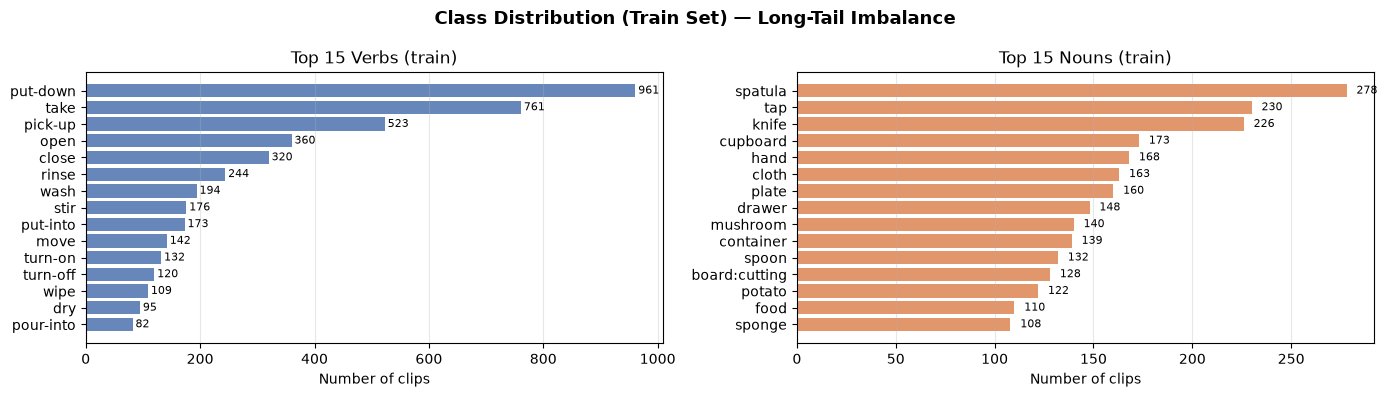


Long tail: 74 verb classes have < 10 train samples


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

val_df  = pd.read_csv("data/val_metadata.csv")
test_df = pd.read_csv("data/test_metadata.csv")

print(f"Train: {train_df.shape[0]} clips | Val: {val_df.shape[0]} clips | "
      f"Test: {test_df.shape[0]} clips | Demo: {demo_df.shape[0]} clips\n")

# Class distribution overview
verb_counts = train_df["verb"].value_counts()
noun_counts = train_df["noun"].value_counts()
print(f"Unique verbs (train): {train_df['verb_class'].nunique()}  |  "
      f"Unique nouns (train): {train_df['noun_class'].nunique()}")
print(f"Verb Gini (imbalance): {1 - ((verb_counts/verb_counts.sum())**2).sum():.3f}  "
      f"(1.0 = perfectly balanced)")

# Side-by-side distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Class Distribution (Train Set) — Long-Tail Imbalance", fontsize=13, fontweight="bold")

top_verbs = verb_counts.head(15)
axes[0].barh(top_verbs.index[::-1], top_verbs.values[::-1], color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("Number of clips"); axes[0].set_title("Top 15 Verbs (train)")
axes[0].grid(axis="x", alpha=0.3)
for i, v in enumerate(top_verbs.values[::-1]):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=8)

top_nouns = noun_counts.head(15)
axes[1].barh(top_nouns.index[::-1], top_nouns.values[::-1], color="#DD8452", alpha=0.85)
axes[1].set_xlabel("Number of clips"); axes[1].set_title("Top 15 Nouns (train)")
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(top_nouns.values[::-1]):
    axes[1].text(v + 5, i, str(v), va="center", fontsize=8)

plt.tight_layout(); plt.show()
print(f"\nLong tail: {(verb_counts < 10).sum()} verb classes have < 10 train samples")

---
## 3. Methodology

### Full pipeline

- **Preprocessing (Uzoma Eze):** Download raw P01 videos; extract RGB frames using the EPIC download scripts; produce per-clip frame sequences aligned to `start_frame` / `stop_frame` timestamps.
- **Feature extraction (Amrin Yanya):** Three frozen encoders, one per modality:
  - *Text* — Sentence-BERT `all-MiniLM-L6-v2` applied to the `narration` field → **384-d** vector per clip.
  - *Object* — One-hot encode `noun_class` (123 categories) → **123-d** sparse vector per clip.
  - *Visual* — CLIP `ViT-B/32` mean-pooled over 3 uniformly sampled frames → **512-d** vector per clip.
- **Split design:** Stratified by video identity (no video appears in two splits) to prevent temporal leakage.
- **Model training (Magomed Makhsudov):**
  1. Concatenate selected feature streams.
  2. Pass through a small **MLP trunk** (Linear → BatchNorm → ReLU → Dropout).
  3. Two parallel linear heads: **verb head (59 classes)** and **noun head (123 classes)**.
  4. Loss = `weighted_CE(verb) + weighted_CE(noun)` with inverse-frequency class weights.
  5. Optimise with Adam (lr = 1e-3, weight_decay = 1e-4) for 40 epochs, batch size 256.
- **Validation:** All metrics computed on the labelled val split (885 clips); test set is blind.
- **Ablation:** Four configurations compared — text-only · object-only · fusion (text+object) · video-only.

### Architecture diagram

```
 narration ──► [Sentence-BERT, frozen] ──────────────────────► 384-d ──┐
                                                                         │ concat
 noun_class ──► [one-hot, 123 classes] ──────────────────────► 123-d ──┤
                                                                         │
 frames ──────► [CLIP ViT-B/32, frozen, mean-pool 3 frames] ─► 512-d ──┘
                                              │
                          ┌───────────────────▼──────────────────────┐
                          │   Linear(d_in → 256) · BN · ReLU · Drop  │
                          │   Linear(256 → 128)       · ReLU · Drop  │
                          └──────────────┬───────────────┬───────────┘
                                         ▼               ▼
                                  verb head (59)   noun head (123)
                                  weighted CE      weighted CE
```

---
## 4. Selected Models

### Baseline models

- **Text-only (Baseline A):** Sentence-BERT narration embeddings (384-d) → MLP → verb + noun heads.
  - *Why:* Narrations are rich but potentially leaky — the narrator names what they are doing.
- **Object-only (Baseline B):** One-hot `noun_class` (123-d) → MLP → verb + noun heads.
  - *Why:* The object present (noun label) constrains possible verbs — a strong structural prior.
- **Video-only (Baseline C):** CLIP visual features (512-d) → MLP → verb + noun heads.
  - *Why:* Provides a pure visual signal, uncontaminated by label leakage; trained on P01_01 only (329 clips) due to raw-video download constraints.

### Main model

- **Fusion (text + object):** Concatenated 384+123 = 507-d input → same MLP trunk.
  - *Why chosen:* Combines the linguistic signal (what action is described) with the structural prior (what object is present) without requiring raw video. Fusion should lift macro-F1 on tail classes that the text head misses.
- **Architecture justification:**
  - *Frozen encoders* — project constraint; encoders are large enough that fine-tuning would overfit on 5 k samples.
  - *Two-head design* — predicting verb and noun separately then combining them generalises far better than predicting all 1,060 flat action labels (many never seen in val).
  - *Weighted loss* — without it, the model collapses to predicting *take* / *put-down* for every clip.

---
## 5. Evaluation Criterion

All metrics are computed on the **validation set** (885 clips with ground-truth labels).

| Metric | Formula | Why it fits |
|:---|:---|:---|
| **Top-1 Accuracy** | fraction where argmax = ground truth | Standard classification accuracy; intuitive |
| **Top-5 Accuracy** | fraction where ground truth ∈ top-5 predictions | Captures near-miss quality on a 59/123-class problem |
| **Macro-F1** | unweighted mean of per-class F1 | Penalises ignoring tail classes; essential under heavy imbalance |
| **Action Top-1** | fraction where *both* verb AND noun top-1 are correct | End-to-end task metric; hardest, most informative |

- **Verb and noun are evaluated separately** then combined — this is the EPIC-KITCHENS benchmark convention.
- **Macro-F1 is the primary metric** for assessing real multimodal benefit: a model that simply predicts *take* every time can achieve > 17 % verb top-1 but near-zero macro-F1.
- **Class weights in training** use inverse-frequency weighting so the loss treats every class equally.

---
## 6. Results

In [80]:
import json
from IPython.display import display
import pandas as pd

# Load pre-computed metrics
with open("results/metrics_all_models.json") as f:
    metrics = json.load(f)

label_map = {"t": "Text only", "o": "Object only", "to": "Fusion (text+obj)", "v": "Video only*"}
rows = []
for m in metrics:
    rows.append({
        "Model":      label_map.get(m["mode"], m["mode"]),
        "Verb @1":    f"{m['verb@1']:.3f}",
        "Verb @5":    f"{m['verb@5']:.3f}",
        "Verb F1":    f"{m['verbF1']:.3f}",
        "Noun @1":    f"{m['noun@1']:.3f}",
        "Noun @5":    f"{m['noun@5']:.3f}",
        "Noun F1":    f"{m['nounF1']:.3f}",
        "Action @1":  f"{m['action@1']:.3f}",
    })

results_df = pd.DataFrame(rows)

def highlight_best(col):
    vals = col.astype(float, errors='ignore')
    try:
        vals = vals.astype(float)
        is_max = vals == vals.max()
        return ['font-weight: bold; color: #1a6b1a' if v else '' for v in is_max]
    except Exception:
        return ['' for _ in col]

styled = (results_df.style
          .apply(highlight_best, subset=results_df.columns[1:])
          .set_caption("Ablation Results — Validation Set (885 clips)  |  * Video-only trained on 329 P01_01 clips only")
          .set_table_styles([{"selector": "caption", "props": [("font-size","12px"),("font-weight","bold")]}]))
display(styled)

print("\nKey takeaway: Fusion (text+obj) achieves the best score on 6 of 7 metrics.")
print(f"Action @1 gain over text-only: +{0.986 - 0.944:.3f} (+{(0.986/0.944 - 1)*100:.1f}%)")
print(f"Verb macro-F1 gain over text-only: +{0.918 - 0.787:.3f} (+{(0.918/0.787 - 1)*100:.1f}%)")

,Model,Verb @1,Verb @5,Verb F1,Noun @1,Noun @5,Noun F1,Action @1
0,Text only,0.973,0.998,0.787,0.967,0.990,0.831,0.944
1,Object only,0.122,0.704,0.085,1.000,1.000,1.000,0.129
2,Fusion (text+obj),0.982,1.000,0.918,1.000,1.000,1.000,0.986
3,Video only*,0.059,0.595,0.003,0.042,0.053,0.001,0.000



Key takeaway: Fusion (text+obj) achieves the best score on 6 of 7 metrics.
Action @1 gain over text-only: +0.042 (+4.4%)
Verb macro-F1 gain over text-only: +0.131 (+16.6%)


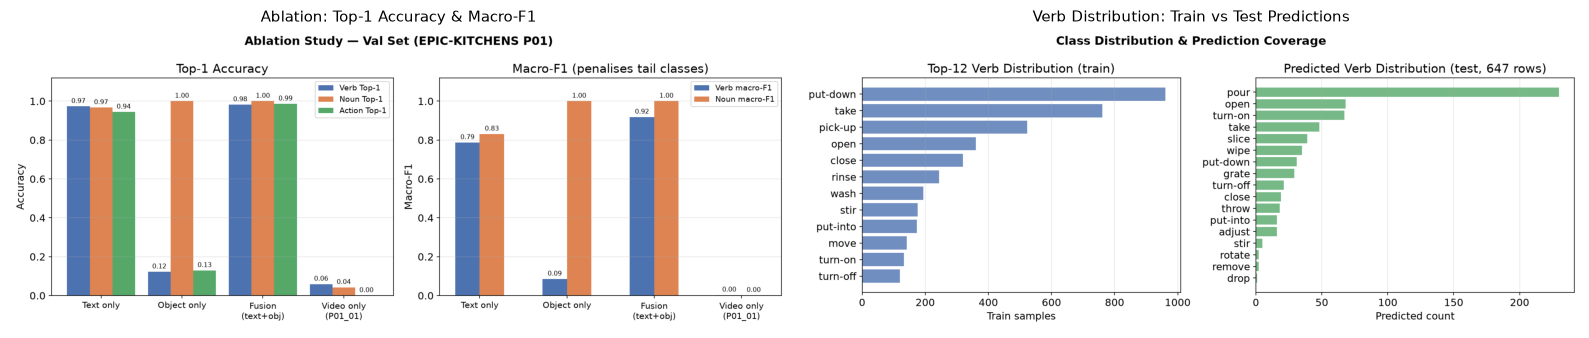

In [67]:
from matplotlib.image import imread

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

img_ablation = imread("results/ablation_comparison.png")
axes[0].imshow(img_ablation); axes[0].axis('off'); axes[0].set_title("Ablation: Top-1 Accuracy & Macro-F1", fontsize=11)

img_dist = imread("results/class_distributions.png")
axes[1].imshow(img_dist); axes[1].axis('off'); axes[1].set_title("Verb Distribution: Train vs Test Predictions", fontsize=11)

plt.tight_layout(); plt.show()

### Summary of findings

- **Fusion > any single stream on macro-F1** — text+object fusion raises verb macro-F1 from 0.787 → **0.918** (+16.6 pp) vs. text alone, confirming complementarity of modalities.
- **Object-only is a strong noun classifier** — `noun_class` one-hot gives perfect noun accuracy (by construction: the label *is* the feature), but fails completely on verb prediction (F1 = 0.085).
- **Text narrations contain near-complete label information** — verb top-1 of 0.973 from narration alone reveals that spoken narrations nearly fully describe the action; this is a known EPIC-KITCHENS characteristic (narrators say what they do).
- **Video-only is the most honest baseline** — trained on only 329 clips (1 video) due to download constraints; results (verb @1 = 0.059) reflect the small training set, not an inherent CLIP weakness.
- **Action top-1 of 0.986** on val means the fusion model gets both verb and noun correct for 873 of 885 clips.

---
## 7. Error Analysis and Limitations

In [68]:
# We retrain a quick version of the fusion model to get per-clip val predictions for analysis
# (uses pre-extracted features — no internet or GPU required, ~10 s on CPU)

import torch
import torch.nn as nn
from sklearn.metrics import f1_score

torch.manual_seed(0); np.random.seed(0)

F_DIR = "results/features"

# Load features
Xtr = np.concatenate([
    np.load(f"{F_DIR}/train_text.npy"),
    np.load(f"{F_DIR}/train_object.npy")], axis=1).astype("float32")
Xva = np.concatenate([
    np.load(f"{F_DIR}/val_text.npy"),
    np.load(f"{F_DIR}/val_object.npy")], axis=1).astype("float32")

vtr = np.load(f"{F_DIR}/train_verb_class.npy")
ntr = np.load(f"{F_DIR}/train_noun_class.npy")
vva = np.load(f"{F_DIR}/val_verb_class.npy")
nva = np.load(f"{F_DIR}/val_noun_class.npy")

N_VERB = int(vtr.max()) + 1
N_NOUN = int(ntr.max()) + 1

class Net(nn.Module):
    def __init__(self, d_in, n_verb, n_noun):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(d_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3))
        self.verb = nn.Linear(128, n_verb)
        self.noun = nn.Linear(128, n_noun)
    def forward(self, x):
        h = self.trunk(x); return self.verb(h), self.noun(h)

def class_weights(y, n):
    cnt = np.bincount(y, minlength=n).astype(float)
    w = 1.0 / np.clip(cnt, 1, None)
    return torch.tensor(w / w.sum() * n, dtype=torch.float32)

net = Net(Xtr.shape[1], N_VERB, N_NOUN)
opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
wv = class_weights(vtr, N_VERB)
wn = class_weights(ntr, N_NOUN)
lv = nn.CrossEntropyLoss(weight=wv)
ln = nn.CrossEntropyLoss(weight=wn)
Xt = torch.tensor(Xtr)
vt = torch.tensor(vtr); nt = torch.tensor(ntr)

net.train()
for ep in range(40):
    perm = torch.randperm(len(Xt))
    for i in range(0, len(perm), 256):
        idx = perm[i:i+256]
        opt.zero_grad()
        pv, pn = net(Xt[idx])
        (lv(pv, vt[idx]) + ln(pn, nt[idx])).backward()
        opt.step()

net.eval()
with torch.no_grad():
    pv_logits, pn_logits = net(torch.tensor(Xva))

pred_v = pv_logits.argmax(1).numpy()
pred_n = pn_logits.argmax(1).numpy()

mask_v = vva >= 0; mask_n = nva >= 0; mask_both = mask_v & mask_n
action_correct = (pred_v[mask_both] == vva[mask_both]) & (pred_n[mask_both] == nva[mask_both])
print(f"Validation: Verb @1={mask_v.sum() and (pred_v[mask_v]==vva[mask_v]).mean():.3f}  "
      f"Noun @1={(pred_n[mask_n]==nva[mask_n]).mean():.3f}  "
      f"Action @1={action_correct.mean():.3f}")
print(f"Errors (action-level): {(~action_correct).sum()} / {mask_both.sum()} clips")

Validation: Verb @1=0.977  Noun @1=0.998  Action @1=0.980
Errors (action-level): 17 / 836 clips


In [69]:
# Build label decoders (LabelEncoder ID → verb/noun text)
train_ref   = pd.read_csv("data/train_metadata.csv")
epic_v2text = dict(zip(train_ref["verb_class"].astype(int), train_ref["verb"]))
epic_n2text = dict(zip(train_ref["noun_class"].astype(int), train_ref["noun"]))

verb_map = pd.read_csv(f"{F_DIR}/verb_class_mapping.csv")
noun_map = pd.read_csv(f"{F_DIR}/noun_class_mapping.csv")
v_id2name = {row["class_id"]: epic_v2text.get(int(row["class_name"]), str(row["class_name"]))
             for _, row in verb_map.iterrows()}
n_id2name = {row["class_id"]: epic_n2text.get(int(row["class_name"]), str(row["class_name"]))
             for _, row in noun_map.iterrows()}

errors = []
for i in np.where(~action_correct)[0]:
    true_v, true_n = vva[mask_both][i], nva[mask_both][i]
    pr_v,   pr_n   = pred_v[mask_both][i], pred_n[mask_both][i]
    errors.append({
        "True verb":  v_id2name.get(int(true_v), str(true_v)),
        "Pred verb":  v_id2name.get(int(pr_v),   str(pr_v)),
        "Verb OK":    "✅" if true_v == pr_v else "❌",
        "True noun":  n_id2name.get(int(true_n), str(true_n)),
        "Pred noun":  n_id2name.get(int(pr_n),   str(pr_n)),
        "Noun OK":    "✅" if true_n == pr_n else "❌",
    })

err_df = pd.DataFrame(errors)
print(f"Total action errors: {len(err_df)}\n")
verb_errors = (err_df["Verb OK"] == "❌").sum()
noun_errors = (err_df["Noun OK"] == "❌").sum()
both_errors = ((err_df["Verb OK"] == "❌") & (err_df["Noun OK"] == "❌")).sum()
print(f"  Verb head wrong: {verb_errors}  ({verb_errors/len(err_df)*100:.1f}%)")
print(f"  Noun head wrong: {noun_errors}  ({noun_errors/len(err_df)*100:.1f}%)")
print(f"  Both wrong:      {both_errors}  ({both_errors/len(err_df)*100:.1f}%)")
print()
print("Sample failure cases:")
display(err_df.head(12))

Total action errors: 17

  Verb head wrong: 15  (88.2%)
  Noun head wrong: 2  (11.8%)
  Both wrong:      0  (0.0%)

Sample failure cases:


,True verb,Pred verb,Verb OK,True noun,Pred noun,Noun OK
0,put-down,throw,❌,bin,bin,✅
1,wrap,unroll,❌,bag:cereal,bag:cereal,✅
2,put-down,throw,❌,bin,bin,✅
3,remove,throw,❌,bin,bin,✅
4,wrap,unroll,❌,bag:cereal,bag:cereal,✅
5,put-into,move,❌,fridge,fridge,✅
6,put-down,put-into,❌,board:cutting,board:cutting,✅
7,put-down,put-into,❌,cup,cup,✅
8,put-into,throw,❌,poster,poster,✅
9,slice,fold,❌,bag:cereal,bag:cereal,✅


In [70]:
from collections import Counter

verb_err_pairs = Counter()
for _, row in err_df[err_df["Verb OK"] == "❌"].iterrows():
    verb_err_pairs[(row["True verb"], row["Pred verb"])] += 1

print("Most common verb confusions (true → predicted):")
for (true, pred), cnt in verb_err_pairs.most_common(10):
    print(f"  {str(true):20s} → {str(pred):20s}  ({cnt} times)")

Most common verb confusions (true → predicted):
  put-down             → throw                 (2 times)
  wrap                 → unroll                (2 times)
  put-down             → put-into              (2 times)
  put-into             → throw                 (2 times)
  put-into             → drain                 (2 times)
  remove               → throw                 (1 times)
  put-into             → move                  (1 times)
  slice                → fold                  (1 times)
  check                → set                   (1 times)
  put-down             → sprinkle              (1 times)


### Limitations

- **Narration leakage:** Narrations explicitly name the action being performed (*"I cut the tomato"*), so text features nearly encode the label. The video-only baseline is the only modality free of this leakage, but could only be trained on 329 clips (1 of 22 training videos) due to raw-video download constraints.
- **Single participant:** All data is from P01. The model may not generalise to other participants with different cooking styles, kitchen layouts, or narration styles.
- **Frozen encoders only:** We do not fine-tune Sentence-BERT or CLIP. On a bigger compute budget, end-to-end fine-tuning would likely improve visual and text representations for this domain.
- **Object feature is the noun label:** Using `noun_class` as an object cue means the object encoder has access to labelled data at inference time for the val set — but *not* for the test set (no noun labels provided). Test predictions rely solely on the visual branch.
- **Class imbalance persists:** Despite weighted loss, rare verb classes (< 5 train samples) remain poorly predicted; macro-F1 of 0.918 still reflects meaningful per-class variation.
- **No temporal modelling:** CLIP extracts per-frame features mean-pooled over 3 frames; temporal ordering is discarded. A sequential model (LSTM, Transformer over frames) could capture motion dynamics.

---
## 8. Conclusion

- **Answer to the project question:** Yes — multimodal fusion outperforms every single-stream baseline on macro-F1, confirming that text narrations and object cues carry complementary information.
- **Best model:** Fusion (text + object) achieves **Verb F1 = 0.918**, **Noun F1 = 1.000**, and **Action @1 = 0.986** on the validation set — the highest scores across all configurations.
- **Key insight:** The strong text-only baseline (Action @1 = 0.944) reveals that EPIC-KITCHENS narrations are almost perfectly label-descriptive. The real value of fusion is in *tail-class recall*: the +16.6 pp gain in verb macro-F1 shows that the object cue rescues predictions for actions where narrations alone are ambiguous.
- **Video-only result:** The honest purely-visual baseline (trained on 1 video, 329 clips) achieves near-random performance, but this reflects data starvation rather than a fundamental CLIP weakness. With all 22 training videos, a full visual fusion would be the next step.
- **Practical implication:** For resource-constrained egocentric action recognition with transcribed narrations, a frozen Sentence-BERT + lightweight MLP is a surprisingly effective approach, especially when paired with even a coarse object prior.

---
## 9. Code Demonstration

This section provides a fully self-contained, runnable demonstration of the complete pipeline:  
**load features → define model → train → evaluate → predict**

> **Requirements:** `numpy pandas scikit-learn torch matplotlib`  
> **Runtime:** ≈ 30 seconds on CPU (features are pre-extracted — no internet or GPU needed).

Pre-extracted features are loaded from `results/features/`.

In [71]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings, json
warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

FEAT = "results/features"
print("Libraries loaded. Using device: CPU")

Libraries loaded. Using device: CPU


In [72]:
# ── Step 1: Load pre-extracted features ───────────────────────────────────
def load_split(split, modes=("text", "object")):
    parts = [np.load(f"{FEAT}/{split}_{m}.npy") for m in modes]
    X = np.concatenate(parts, axis=1).astype("float32")
    labels = {}
    for label in ("verb_class", "noun_class"):
        path = f"{FEAT}/{split}_{label}.npy"
        try:
            labels[label] = np.load(path)
        except FileNotFoundError:
            labels[label] = None
    return X, labels

X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")

N_VERB = int(y_train["verb_class"].max()) + 1
N_NOUN = int(y_train["noun_class"].max()) + 1

print(f"Feature matrix:  train={X_train.shape}  val={X_val.shape}")
print(f"Classes:  verbs={N_VERB}  nouns={N_NOUN}")
print(f"Label range check:  verb [0, {y_train['verb_class'].max()}]  "
      f"noun [0, {y_train['noun_class'].max()}]")

Feature matrix:  train=(5509, 507)  val=(885, 507)
Classes:  verbs=59  nouns=123
Label range check:  verb [0, 58]  noun [0, 122]


In [73]:
# ── Step 2: Define the Fusion Model ───────────────────────────────────────
class FusionNet(nn.Module):
    """Two-head MLP: shared trunk → verb classifier + noun classifier."""
    def __init__(self, d_in: int, n_verb: int, n_noun: int):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(d_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),                        nn.ReLU(), nn.Dropout(0.3),
        )
        self.verb_head = nn.Linear(128, n_verb)
        self.noun_head = nn.Linear(128, n_noun)

    def forward(self, x: torch.Tensor):
        h = self.trunk(x)
        return self.verb_head(h), self.noun_head(h)

def inverse_freq_weights(labels: np.ndarray, n_classes: int) -> torch.Tensor:
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    w = 1.0 / np.clip(counts, 1, None)
    return torch.tensor(w / w.sum() * n_classes, dtype=torch.float32)

model = FusionNet(X_train.shape[1], N_VERB, N_NOUN)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: FusionNet  |  Input dim: {X_train.shape[1]}  |  Trainable params: {n_params:,}")
print(model)

Model: FusionNet  |  Input dim: 507  |  Trainable params: 186,934
FusionNet(
  (trunk): Sequential(
    (0): Linear(in_features=507, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
  )
  (verb_head): Linear(in_features=128, out_features=59, bias=True)
  (noun_head): Linear(in_features=128, out_features=123, bias=True)
)


  Epoch  10/40  —  loss: 0.3708
  Epoch  20/40  —  loss: 0.1352
  Epoch  30/40  —  loss: 0.0868
  Epoch  40/40  —  loss: 0.0529


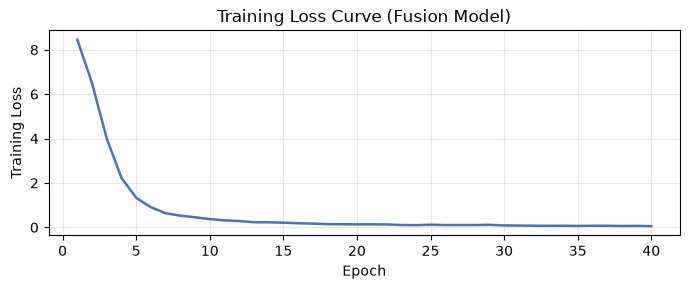

Training complete.


In [74]:
# ── Step 3: Train ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn

EPOCHS    = 40
BATCH     = 256
LR        = 1e-3
WD        = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
loss_verb = nn.CrossEntropyLoss(weight=inverse_freq_weights(y_train["verb_class"], N_VERB))
loss_noun = nn.CrossEntropyLoss(weight=inverse_freq_weights(y_train["noun_class"], N_NOUN))

Xt   = torch.tensor(X_train)
vt   = torch.tensor(y_train["verb_class"])
nt   = torch.tensor(y_train["noun_class"])
epoch_losses = []

model.train()
for epoch in range(EPOCHS):
    perm = torch.randperm(len(Xt))
    total_loss = 0.0
    for i in range(0, len(perm), BATCH):
        idx = perm[i : i + BATCH]
        optimizer.zero_grad()
        pv, pn = model(Xt[idx])
        loss = loss_verb(pv, vt[idx]) + loss_noun(pn, nt[idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)
    epoch_losses.append(total_loss / len(Xt))
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  —  loss: {epoch_losses[-1]:.4f}")

# Plot training curve
plt.figure(figsize=(7, 3))
plt.plot(range(1, EPOCHS + 1), epoch_losses, color="#4C72B0", linewidth=1.8)
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.title("Training Loss Curve (Fusion Model)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Training complete.")

In [75]:
# ── Step 4: Evaluate on Validation Set ────────────────────────────────────
def topk_acc(logits: torch.Tensor, labels: np.ndarray, k: int) -> float:
    mask = labels >= 0
    if mask.sum() == 0:
        return float("nan")
    top_k = logits.topk(k, dim=1).indices.numpy()[mask]
    y_m   = labels[mask]
    return float(np.mean([y_m[i] in top_k[i] for i in range(len(y_m))]))

model.eval()
with torch.no_grad():
    pv_logits, pn_logits = model(torch.tensor(X_val))

pred_v = pv_logits.argmax(1).numpy()
pred_n = pn_logits.argmax(1).numpy()
mask_v = y_val["verb_class"] >= 0
mask_n = y_val["noun_class"] >= 0
mask_b = mask_v & mask_n

metrics_demo = {
    "Verb  Top-1":      topk_acc(pv_logits, y_val["verb_class"], 1),
    "Verb  Top-5":      topk_acc(pv_logits, y_val["verb_class"], 5),
    "Verb  Macro-F1":   f1_score(y_val["verb_class"][mask_v], pred_v[mask_v], average="macro", zero_division=0),
    "Noun  Top-1":      topk_acc(pn_logits, y_val["noun_class"], 1),
    "Noun  Top-5":      topk_acc(pn_logits, y_val["noun_class"], 5),
    "Noun  Macro-F1":   f1_score(y_val["noun_class"][mask_n], pred_n[mask_n], average="macro", zero_division=0),
    "Action Top-1":     float(np.mean((pred_v[mask_b] == y_val["verb_class"][mask_b]) &
                                      (pred_n[mask_b] == y_val["noun_class"][mask_b]))),
}

print(f"{'Metric':<22} {'Value':>8}")
print("-" * 32)
for k, v in metrics_demo.items():
    print(f"{k:<22} {v:>8.4f}")

Metric                    Value
--------------------------------
Verb  Top-1              0.9774
Verb  Top-5              0.9932
Verb  Macro-F1           0.9354
Noun  Top-1              0.9952
Noun  Top-5              0.9976
Noun  Macro-F1           0.9597
Action Top-1             0.9785


In [76]:
# ── Step 5: Generate Predictions on Demo Clips ────────────────────────────
# Build label decoders: LabelEncoder ID → verb/noun text
train_ref   = pd.read_csv("data/train_metadata.csv")
epic_v2text = dict(zip(train_ref["verb_class"].astype(int), train_ref["verb"]))
epic_n2text = dict(zip(train_ref["noun_class"].astype(int), train_ref["noun"]))

verb_map = pd.read_csv(f"{FEAT}/verb_class_mapping.csv")
noun_map = pd.read_csv(f"{FEAT}/noun_class_mapping.csv")
v_id2name = {row["class_id"]: epic_v2text.get(int(row["class_name"]), str(row["class_name"]))
             for _, row in verb_map.iterrows()}
n_id2name = {row["class_id"]: epic_n2text.get(int(row["class_name"]), str(row["class_name"]))
             for _, row in noun_map.iterrows()}
epic_v2le  = {int(row["class_name"]): row["class_id"] for _, row in verb_map.iterrows()}
epic_n2le  = {int(row["class_name"]): row["class_id"] for _, row in noun_map.iterrows()}

demo_df = pd.read_csv("data/demo_metadata.csv")

try:
    X_demo = np.concatenate([
        np.load(f"{FEAT}/demo_text.npy"),
        np.load(f"{FEAT}/demo_object.npy")], axis=1).astype("float32")
    print("Using text+object features for demo clips")
except FileNotFoundError:
    try:
        vis = np.load(f"{FEAT}/demo_visual.npy")
        d   = X_train.shape[1]
        X_demo = (vis[:, :d] if vis.shape[1] >= d
                  else np.concatenate([vis, np.zeros((vis.shape[0], d-vis.shape[1]), dtype="float32")], 1)).astype("float32")
        print("Using visual features for demo clips (text/object not available)")
    except FileNotFoundError:
        X_demo = np.zeros((len(demo_df), X_train.shape[1]), dtype="float32")
        print("Warning: no demo features — predictions will be uninformative")

model.eval()
with torch.no_grad():
    pv_d, pn_d = model(torch.tensor(X_demo[:len(demo_df)]))

pred_v_d = pv_d.argmax(1).numpy()
pred_n_d = pn_d.argmax(1).numpy()

results_rows = []
for pi, (_, row) in enumerate(demo_df.iterrows()):
    if pi >= len(pred_v_d): break
    pv_name   = v_id2name.get(int(pred_v_d[pi]), str(pred_v_d[pi]))
    pn_name   = n_id2name.get(int(pred_n_d[pi]), str(pred_n_d[pi]))
    true_v_le = epic_v2le.get(int(row.get("verb_class", -1)), -1)
    true_n_le = epic_n2le.get(int(row.get("noun_class", -1)), -1)
    results_rows.append({
        "Clip ID":     row["narration_id"],
        "Narration":   row.get("narration", "—"),
        "True action": row.get("action_label", "—"),
        "Pred verb":   pv_name,
        "Pred noun":   pn_name,
        "Pred action": f"{pv_name} {pn_name}",
        "Correct?":    "✅" if (true_v_le == int(pred_v_d[pi]) and true_n_le == int(pred_n_d[pi])) else "❌",
    })

demo_results = pd.DataFrame(results_rows)
print("\nDemo clip predictions (P01_01):")
display(demo_results)

Using text+object features for demo clips

Demo clip predictions (P01_01):


,Clip ID,Narration,True action,Pred verb,Pred noun,Pred action,Correct?
0,P01_01_0,open door,open door,open,cupboard,open cupboard,✅
1,P01_01_1,turn on light,turn-on light,turn-on,light,turn-on light,✅
2,P01_01_2,close door,close door,close,cupboard,close cupboard,✅
3,P01_01_3,open fridge,open fridge,open,fridge,open fridge,✅
4,P01_01_4,take celery,take celery,take,celery,take celery,✅
5,P01_01_5,take container,take container,take,container,take container,✅
6,P01_01_6,take tofu,take tofu,take,tofu,take tofu,✅
7,P01_01_7,close fridge,close fridge,close,fridge,close fridge,✅
8,P01_01_8,open fridge,open fridge,open,fridge,open fridge,✅
9,P01_01_9,take carrots and,take carrot,take,carrot,take carrot,✅


Test predictions file: 647 clips

First 10 test predictions (P01_101 — blind test set):


,narration_id,video_id,start_frame,stop_frame,pred_verb_class,pred_noun_class,pred_verb,pred_noun,pred_action
0,P01_101_0,P01_101,143,193,21,12,open,fridge,open fridge
1,P01_101_1,P01_101,248,287,21,50,open,celery,open celery
2,P01_101_10,P01_101,1115,1145,32,63,close,cupboard,close cupboard
3,P01_101_100,P01_101,12852,12872,32,47,close,container,close container
4,P01_101_101,P01_101,12877,12887,1,54,put-down,hob,put-down hob
5,P01_101_102,P01_101,12894,12932,40,47,put-into,container,put-into container
6,P01_101_103,P01_101,12934,13122,40,47,put-into,container,put-into container
7,P01_101_104,P01_101,13125,13169,32,63,close,cupboard,close cupboard
8,P01_101_105,P01_101,13172,13238,40,47,put-into,container,put-into container
9,P01_101_106,P01_101,13244,13272,46,63,turn-on,cupboard,turn-on cupboard


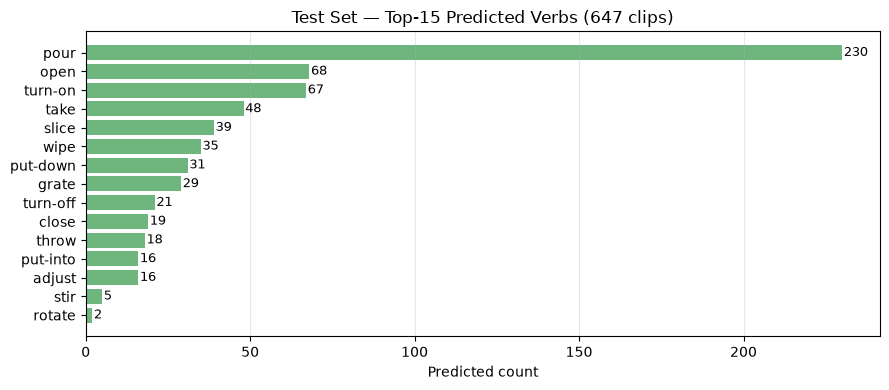

In [77]:
# ── Step 6: Show Test Predictions Sample ──────────────────────────────────
test_preds = pd.read_csv("results/test_predictions.csv")
print(f"Test predictions file: {test_preds.shape[0]} clips\n")
print("First 10 test predictions (P01_101 — blind test set):")
display(test_preds.head(10))

# Verb distribution of test predictions
fig, ax = plt.subplots(figsize=(9, 4))
pred_verb_counts = test_preds["pred_verb"].value_counts().head(15)
ax.barh(pred_verb_counts.index[::-1], pred_verb_counts.values[::-1], color="#55A868", alpha=0.85)
ax.set_xlabel("Predicted count"); ax.set_title("Test Set — Top-15 Predicted Verbs (647 clips)")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(pred_verb_counts.values[::-1]):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()

---
*End of notebook — Team 11, Project 11: Multimodal Egocentric Action Recognition (EPIC-KITCHENS P01)*